# 🧬 Bioprocess Analytics & PAT Modeling
## Cell Expansion Monitoring

**Pipeline overview:**
1. Data Simulation & Integration — **20 batches × 2,600 points = 52,000 rows**
2. ETL Pipeline — Raw → Staging → Analytics-Ready (SQLite)
3. Exploratory Data Analysis (correlation, distributions, time-series)
4. Model Development — Random Forest & Ridge Regression
5. Spectral Processing & Chemometrics (PLS)
6. Unsupervised Learning & Anomaly Detection (K-Means)
7. Final Report

---

In [19]:
# ── Imports & configuration ──────────────────────────────────────
import os, sqlite3, warnings, time
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)
%matplotlib inline

# Output directories
BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
FIG_DIR    = os.path.join(OUTPUT_DIR, 'figures')
DB_PATH    = os.path.join(OUTPUT_DIR, 'bioprocess.db')
for d in [OUTPUT_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

TRACEABILITY_LOG = []
print(' Environment ready')

 Environment ready


## Section 1 — Data Simulation & Integration

In [20]:
def simulate_online_data(n_batches=20, points_per_batch=2600):
    """
    Simulate online in-process measurements for multiple bioreactor batches.
    Default: 20 batches × 2,600 points = 52,000 rows (satisfies ≥50,000 requirement).
    Measurements: biocapacitance, pH, dissolved oxygen (DO), temperature.
    """
    records = []
    batch_start = datetime(2024, 1, 1)
    for batch_id in range(1, n_batches + 1):
        rng = np.random.RandomState(batch_id * 7)
        t = np.linspace(0, 48, points_per_batch)  # hours 0–48
        cap_max = rng.uniform(80, 120)
        # Biocapacitance: logistic growth + noise
        biocap = cap_max / (1 + np.exp(-rng.uniform(0.10,0.18)*(t-24))) + rng.normal(0, 1.5, points_per_batch)
        # pH: slight drift from 7.2 → 6.8
        ph = 7.2 - 0.4*(t/48) + rng.normal(0, 0.02, points_per_batch)
        # Dissolved oxygen: inverse of growth
        do = np.clip(80 - 50*(biocap/cap_max) + rng.normal(0,2,points_per_batch), 5, 100)
        # Temperature: 37°C setpoint + oscillations
        temp = 37.0 + 0.3*np.sin(2*np.pi*t/12) + rng.normal(0, 0.05, points_per_batch)
        timestamps = [batch_start + timedelta(hours=float(h)) for h in t]
        for i in range(points_per_batch):
            records.append({'batch_id': f'BATCH_{batch_id:03d}', 'timestamp': timestamps[i],
                            'process_hour': t[i], 'biocapacitance': round(biocap[i],4),
                            'pH': round(ph[i],4), 'dissolved_oxygen': round(do[i],4),
                            'temperature': round(temp[i],4)})
        batch_start += timedelta(days=3)
    return pd.DataFrame(records)


def simulate_offline_assay_data(online_df, sample_interval_hrs=4):
    """Simulate offline VCD, viability, glucose, glutamine, lactate measurements."""
    records = []
    for batch_id, grp in online_df.groupby('batch_id'):
        rng = np.random.RandomState(int(batch_id.split('_')[1]) * 13)
        for h in np.arange(0, 49, sample_interval_hrs):
            vcd_max = rng.uniform(15, 25)
            vcd     = max(vcd_max/(1+np.exp(-0.15*(h-24)))+rng.normal(0,0.5), 0.5)
            viab    = np.clip(98-0.3*max(h-30,0)+rng.normal(0,0.8), 60, 100)
            gluc    = max(25-0.4*h+rng.normal(0,0.5), 0.5)
            glut    = max(4-0.07*h+rng.normal(0,0.15), 0.1)
            lact    = max(0.5+0.35*h+rng.normal(0,0.4), 0)
            records.append({'batch_id': batch_id, 'process_hour': float(h),
                            'vcd': round(vcd,4), 'viability_pct': round(viab,2),
                            'glucose_mM': round(gluc,4), 'glutamine_mM': round(glut,4),
                            'lactate_mM': round(lact,4)})
    return pd.DataFrame(records)


def build_master_matrix(online_df, offline_df):
    """
    Merge online and offline data via merge_asof per batch.
    Output row count = online row count (n_batches × points_per_batch).
    """
    on = online_df.sort_values(['batch_id','process_hour'])
    off = offline_df.sort_values(['batch_id','process_hour'])
    parts = []
    for bid in on['batch_id'].unique():
        parts.append(pd.merge_asof(on[on.batch_id==bid], off[off.batch_id==bid],
                                   on='process_hour', by='batch_id', direction='nearest'))
    return pd.concat(parts, ignore_index=True)


# 20 batches × 2,600 points = 52,000 rows 
online_df  = simulate_online_data(n_batches=20, points_per_batch=2600)
offline_df = simulate_offline_assay_data(online_df)
master_df  = build_master_matrix(online_df, offline_df)

assert len(master_df) >= 50_000, f'Only {len(master_df):,} rows – expected ≥50,000'
print(f' Master matrix: {len(master_df):,} rows × {master_df.shape[1]} columns')
master_df.head()

 Master matrix: 52,000 rows × 12 columns


,batch_id,timestamp,process_hour,biocapacitance,pH,dissolved_oxygen,temperature,vcd,viability_pct,glucose_mM,glutamine_mM,lactate_mM
0,BATCH_001,2024-01-01 00:00:00.000000,0.000000,4.1877,7.1999,78.9727,36.9690,0.9366,97.57,26.1033,3.8587,0.753
1,BATCH_001,2024-01-01 00:01:06.487110,0.018469,0.9579,7.1864,76.9647,37.0261,0.9366,97.57,26.1033,3.8587,0.753
2,BATCH_001,2024-01-01 00:02:12.974221,0.036937,1.7109,7.1917,77.4817,37.0421,0.9366,97.57,26.1033,3.8587,0.753
3,BATCH_001,2024-01-01 00:03:19.461331,0.055406,2.2778,7.2082,78.7058,36.9794,0.9366,97.57,26.1033,3.8587,0.753
4,BATCH_001,2024-01-01 00:04:25.948442,0.073875,0.4881,7.1774,77.9864,36.9946,0.9366,97.57,26.1033,3.8587,0.753


## Section 2 — ETL Pipeline (Raw → Staging → Analytics)

In [21]:
def _log(stage, action, details):
    """Append ETL traceability entry."""
    TRACEABILITY_LOG.append({'timestamp': datetime.now().isoformat(),
                             'stage': stage, 'action': action, 'details': details})

conn = sqlite3.connect(DB_PATH)

# ── RAW stage: inject ~2% nulls to simulate sensor drop-outs ──────
df_raw = master_df.copy()
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
for _ in range(int(0.02 * len(df_raw) * len(num_cols))):
    df_raw.at[np.random.randint(0,len(df_raw)), np.random.choice(num_cols)] = np.nan
df_raw.to_sql('raw_data', conn, if_exists='replace', index=False)
_log('RAW','load', f'{len(df_raw):,} rows, {df_raw.isnull().sum().sum()} nulls injected')
print(f'[RAW] {len(df_raw):,} rows stored | nulls: {df_raw.isnull().sum().sum()}')

# ── STAGING stage: impute, clip, quality flag ─────────────────────
df_stg = df_raw.copy()
# Forward-fill within batch, then median fallback
df_stg[num_cols] = df_stg.groupby('batch_id')[num_cols].transform(lambda x: x.ffill().bfill())
for col in num_cols:
    df_stg[col] = df_stg[col].fillna(df_stg[col].median())
# Physical range clipping
clip_rules = {'biocapacitance':(0,200),'pH':(6,8),'dissolved_oxygen':(0,100),'temperature':(34,40)}
for col,(lo,hi) in clip_rules.items():
    if col in df_stg.columns:
        df_stg[col] = df_stg[col].clip(lo, hi)
df_stg['quality_flag'] = np.where(df_stg['dissolved_oxygen']<10,'WARN_LOW_DO','OK')
df_stg.to_sql('staging_data', conn, if_exists='replace', index=False)
_log('STAGING','clean','Imputed + clipped + quality flags added')
print(f'[STAGING] {len(df_stg):,} rows | WARN rows: {(df_stg.quality_flag=="WARN_LOW_DO").sum()}')

# ── ANALYTICS stage: normalize + rolling features ─────────────────
df_ana = df_stg[df_stg.quality_flag=='OK'].copy()
feat_cols = [c for c in ['biocapacitance','pH','dissolved_oxygen','temperature',
                          'vcd','viability_pct','glucose_mM','glutamine_mM','lactate_mM']
             if c in df_ana.columns]
scaler = StandardScaler()
df_ana[[f'{c}_norm' for c in feat_cols]] = scaler.fit_transform(df_ana[feat_cols].values)
for col in ['biocapacitance','pH','dissolved_oxygen']:
    if col in df_ana.columns:
        df_ana[f'{col}_roll10'] = df_ana.groupby('batch_id')[col].transform(
            lambda x: x.rolling(10,min_periods=1).mean())
df_ana.to_sql('analytics_data', conn, if_exists='replace', index=False)
_log('ANALYTICS','normalize+rolling',f'{len(df_ana):,} rows written')
print(f'[ANALYTICS] {len(df_ana):,} rows ready')

# Persist ETL traceability log
pd.DataFrame(TRACEABILITY_LOG).to_sql('etl_log', conn, if_exists='replace', index=False)
print(f'[ETL-LOG] {len(TRACEABILITY_LOG)} traceability records saved')

[RAW] 52,000 rows stored | nulls: 10307
[STAGING] 52,000 rows | WARN rows: 0
[ANALYTICS] 52,000 rows ready
[ETL-LOG] 3 traceability records saved


## Section 3 — Exploratory Data Analysis

In [22]:
numeric_cols = [c for c in ['biocapacitance','pH','dissolved_oxygen','temperature',
                              'vcd','viability_pct','glucose_mM','glutamine_mM','lactate_mM']
                if c in df_ana.columns]

print('── Summary Statistics ──')
display(df_ana[numeric_cols].describe().T.round(3))

── Summary Statistics ──


,count,mean,std,min,25%,50%,75%,max
biocapacitance,52000.0,49.450,33.499,0.000,16.247,48.474,78.343,118.845
pH,52000.0,7.000,0.117,6.743,6.899,7.000,7.100,7.255
dissolved_oxygen,52000.0,54.992,16.572,22.721,38.491,55.027,71.479,86.551
temperature,52000.0,37.000,0.218,36.518,36.796,36.999,37.205,37.490
vcd,52000.0,10.234,7.183,0.500,2.787,9.786,16.873,24.154
viability_pct,52000.0,96.908,1.822,90.620,96.010,97.400,98.190,100.000
glucose_mM,52000.0,15.401,5.598,5.271,10.577,15.338,20.440,26.103
glutamine_mM,52000.0,2.319,0.972,0.450,1.468,2.305,3.160,4.188
lactate_mM,52000.0,8.919,4.935,0.000,4.824,8.761,13.310,18.035


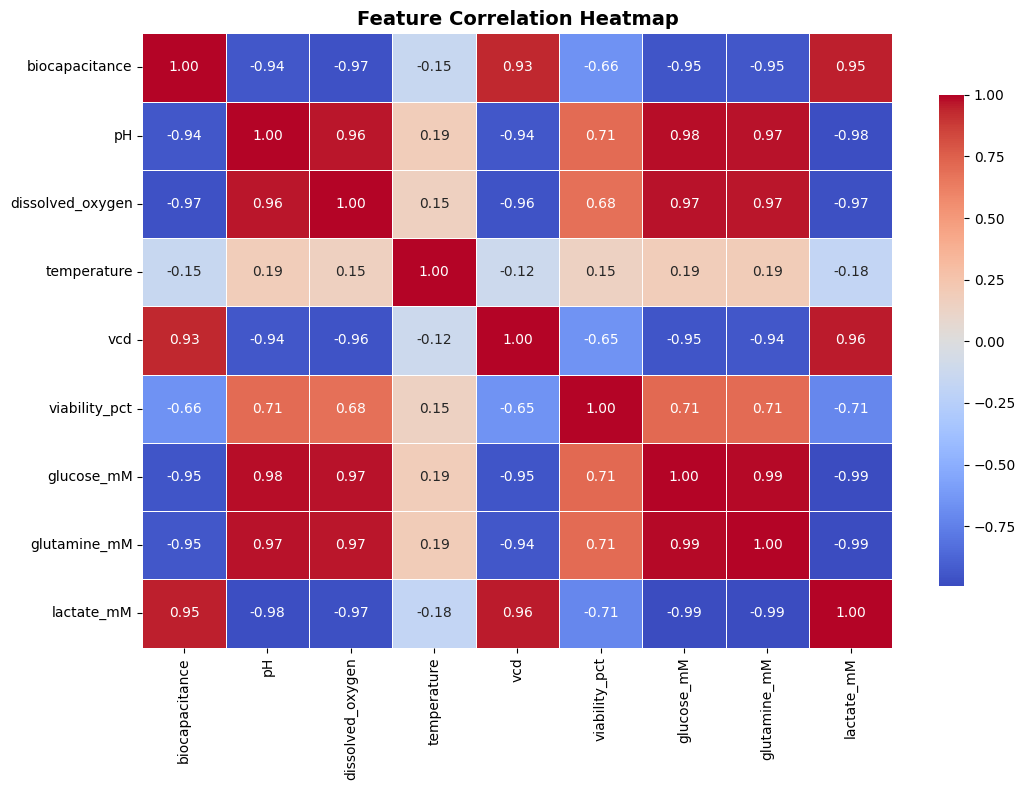

In [23]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(11,8))
sns.heatmap(df_ana[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR,'eda_correlation_heatmap.png'), dpi=120)
plt.show()

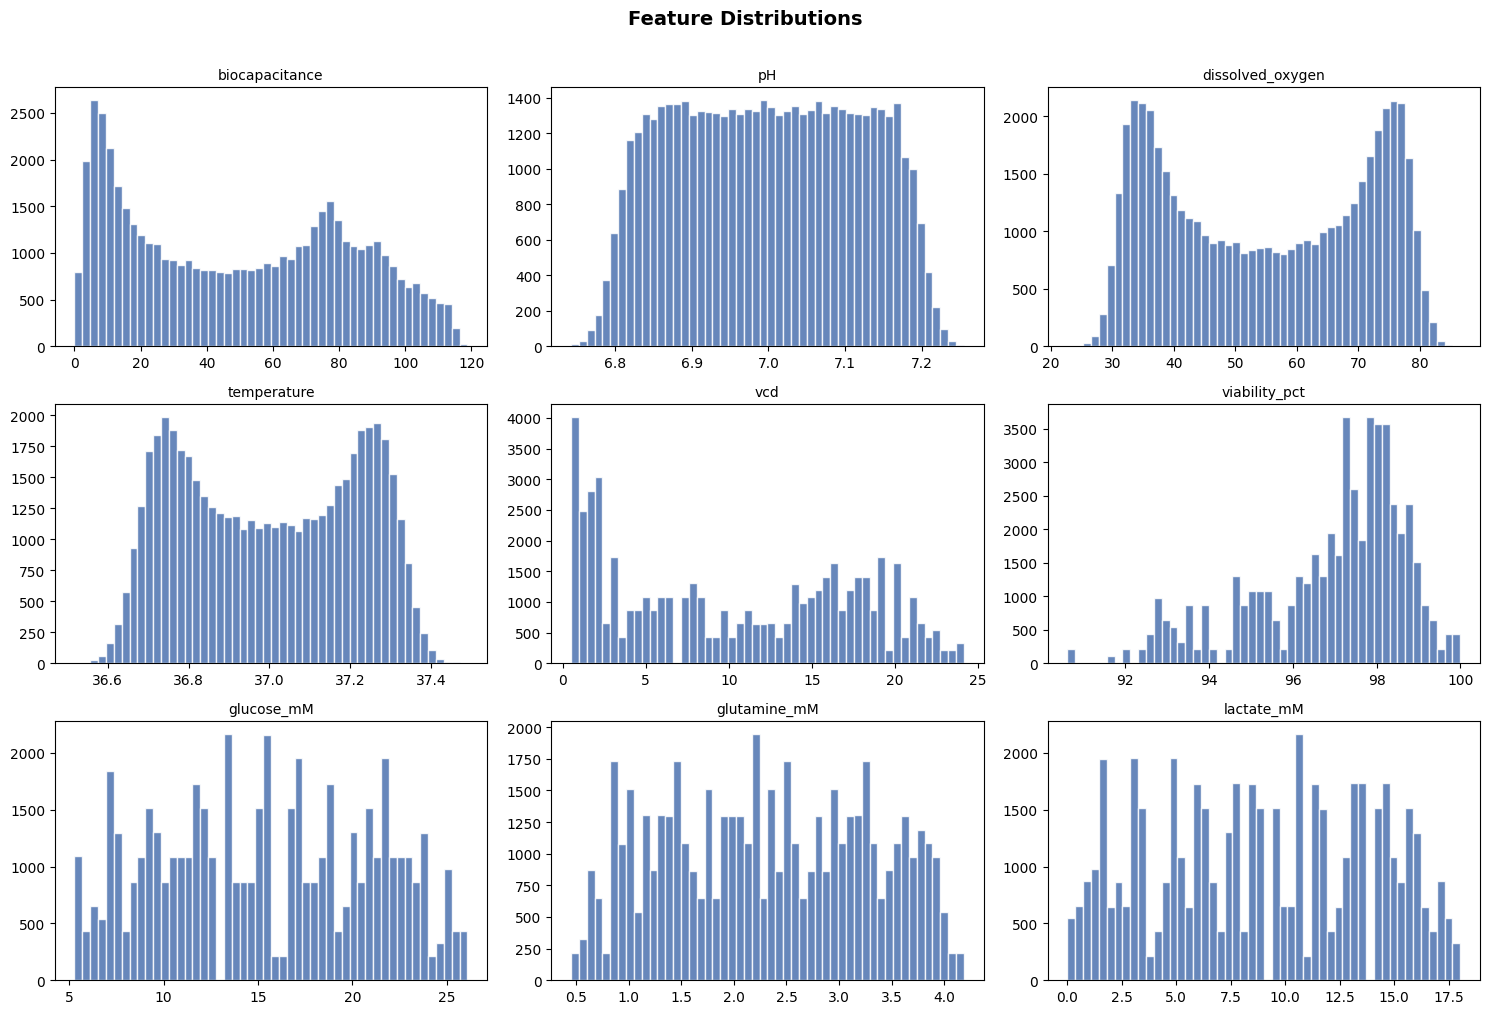

In [24]:
# Distributions
fig, axes = plt.subplots(3,3,figsize=(15,10))
for i, col in enumerate(numeric_cols[:9]):
    axes.flatten()[i].hist(df_ana[col].dropna(), bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes.flatten()[i].set_title(col, fontsize=10)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR,'eda_distributions.png'), dpi=120)
plt.show()

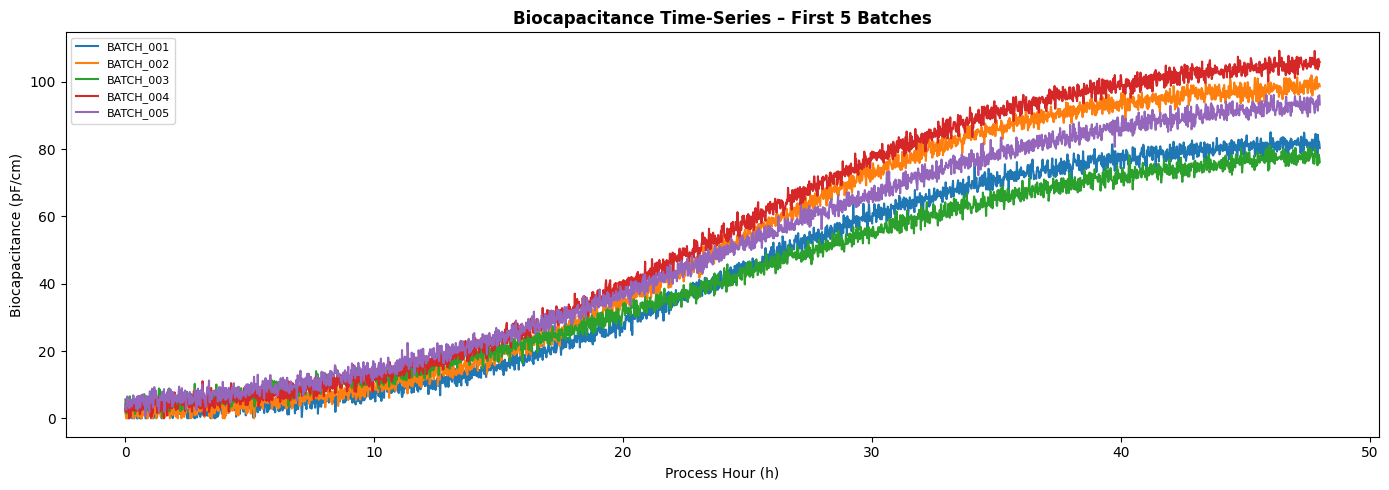

In [25]:
# Biocapacitance time-series – first 5 batches
sample_batches = sorted(df_ana['batch_id'].unique())[:5]
palette = sns.color_palette('tab10', 5)

fig, ax = plt.subplots(figsize=(14,5))
for idx, bid in enumerate(sample_batches):
    grp = df_ana[df_ana.batch_id==bid].sort_values('process_hour')
    ax.plot(grp.process_hour, grp.biocapacitance, label=bid, color=palette[idx], lw=1.5)
ax.set_xlabel('Process Hour (h)')
ax.set_ylabel('Biocapacitance (pF/cm)')
ax.set_title('Biocapacitance Time-Series – First 5 Batches', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR,'eda_biocap_timeseries.png'), dpi=120)
plt.show()

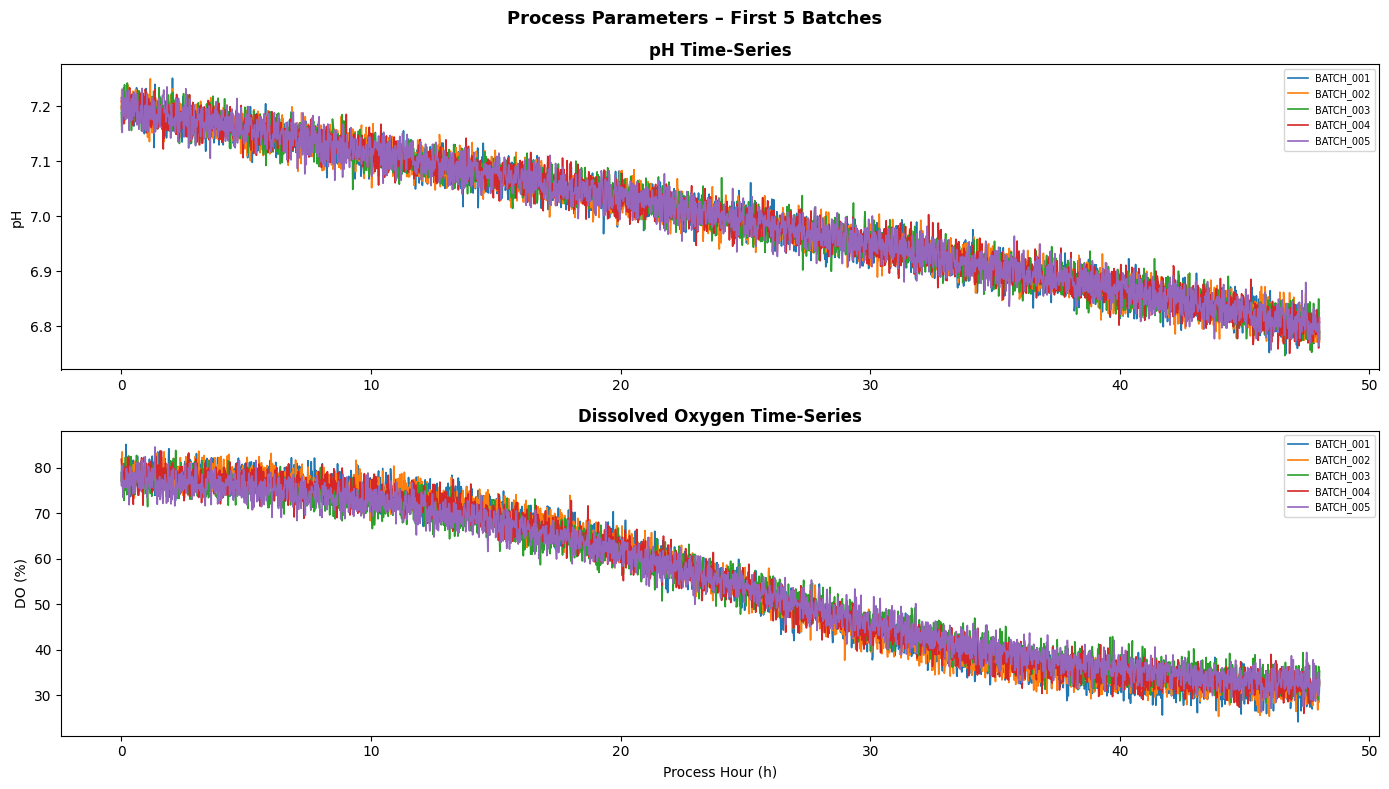

In [26]:
# pH and DO time-series
fig, axes = plt.subplots(2,1,figsize=(14,8))
for idx, bid in enumerate(sample_batches):
    grp = df_ana[df_ana.batch_id==bid].sort_values('process_hour')
    axes[0].plot(grp.process_hour, grp.pH, label=bid, color=palette[idx], lw=1.2)
    axes[1].plot(grp.process_hour, grp.dissolved_oxygen, label=bid, color=palette[idx], lw=1.2)
axes[0].set_title('pH Time-Series', fontweight='bold'); axes[0].set_ylabel('pH')
axes[1].set_title('Dissolved Oxygen Time-Series', fontweight='bold'); axes[1].set_ylabel('DO (%)')
axes[1].set_xlabel('Process Hour (h)')
for ax in axes: ax.legend(fontsize=7)
plt.suptitle('Process Parameters – First 5 Batches', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR,'eda_ph_do_timeseries.png'), dpi=120)
plt.show()

## Section 4 — Model Development (Random Forest & Ridge)

In [27]:
# Prepare ML dataset – predict VCD from online process parameters
feature_cols = [c for c in ['biocapacitance','pH','dissolved_oxygen','temperature','process_hour']
                if c in df_ana.columns]
ml_df  = df_ana[feature_cols + ['vcd']].dropna()
X, y   = ml_df[feature_cols].values, ml_df['vcd'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_tr.shape[0]:,}  |  Test: {X_te.shape[0]:,}')

Train: 41,600  |  Test: 10,400


In [ ]:
# ── Random Forest with GridSearchCV ─────────────────────────────
gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators':[100,200],'max_depth':[None,10],'min_samples_split':[2,5]},
    cv=3, scoring='r2', n_jobs=-1
)
gs_rf.fit(X_tr, y_tr)
rf_best = gs_rf.best_estimator_
y_pred_rf = rf_best.predict(X_te)

r2_rf   = r2_score(y_te, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_te, y_pred_rf))
mae_rf  = mean_absolute_error(y_te, y_pred_rf)
cv_rf   = cross_val_score(rf_best, X_tr, y_tr, cv=5, scoring='r2').mean()
print(f'[RandomForest] R²={r2_rf:.4f}  RMSE={rmse_rf:.4f}  MAE={mae_rf:.4f}  CV-R²={cv_rf:.4f}')
print(f'Best params: {gs_rf.best_params_}')

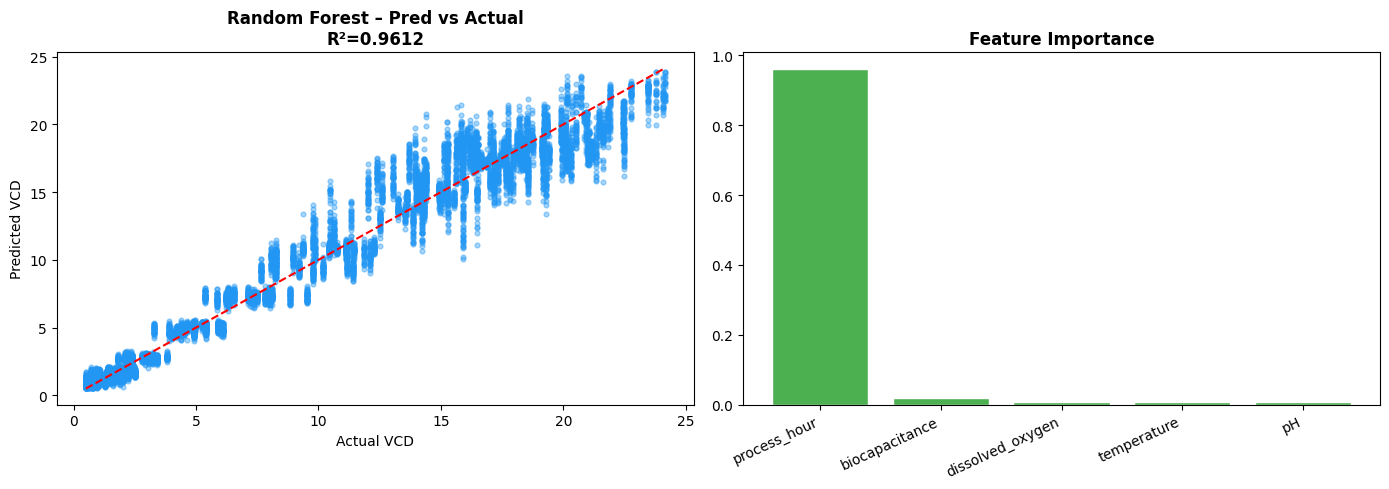

In [ ]:
# RF: Predicted vs Actual + Feature Importance
fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].scatter(y_te, y_pred_rf, alpha=0.4, s=12, color='#2196F3')
lims=[min(y_te.min(),y_pred_rf.min()),max(y_te.max(),y_pred_rf.max())]
axes[0].plot(lims,lims,'r--',lw=1.5)
axes[0].set_xlabel('Actual VCD'); axes[0].set_ylabel('Predicted VCD')
axes[0].set_title(f'Random Forest – Pred vs Actual\nR²={r2_rf:.4f}', fontweight='bold')

imp = rf_best.feature_importances_
sidx = np.argsort(imp)[::-1]
axes[1].bar(range(len(imp)), imp[sidx], color='#4CAF50', edgecolor='white')
axes[1].set_xticks(range(len(imp)))
axes[1].set_xticklabels([feature_cols[i] for i in sidx], rotation=25, ha='right')
axes[1].set_title('Feature Importance', fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR,'rf_pred_importance.png'), dpi=120)
plt.show()

[Ridge] R²=0.9251  RMSE=1.9663  MAE=1.5088  CV-R²=0.9251


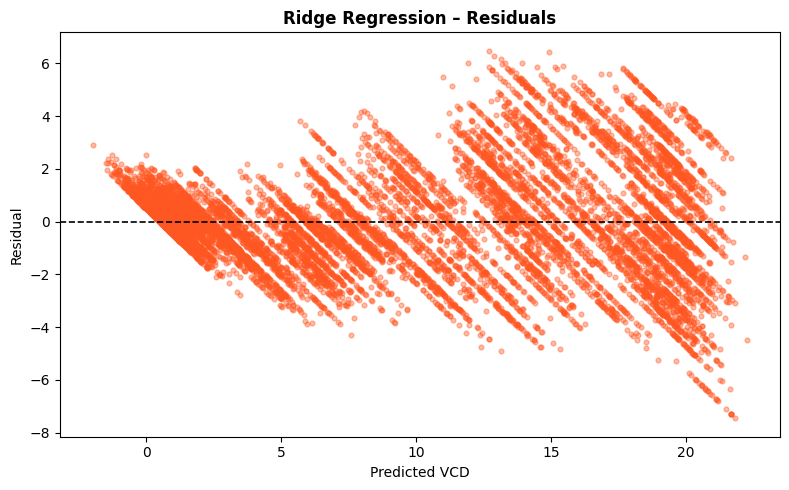

In [ ]:
# ── Ridge Regression (StandardScaler pipeline) ───────────────────
pipe_ridge = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
gs_ridge = GridSearchCV(pipe_ridge, {'ridge__alpha':[0.01,0.1,1,10,100]}, cv=5, scoring='r2')
gs_ridge.fit(X_tr, y_tr)
ridge_best = gs_ridge.best_estimator_
y_pred_ridge = ridge_best.predict(X_te)

r2_ridge   = r2_score(y_te, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_te, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_te, y_pred_ridge)
cv_ridge   = cross_val_score(ridge_best, X_tr, y_tr, cv=5, scoring='r2').mean()
print(f'[Ridge] R²={r2_ridge:.4f}  RMSE={rmse_ridge:.4f}  MAE={mae_ridge:.4f}  CV-R²={cv_ridge:.4f}')

# Residual plot
resid = y_te - y_pred_ridge
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(y_pred_ridge, resid, alpha=0.4, s=12, color='#FF5722')
ax.axhline(0, color='black', lw=1.2, ls='--')
ax.set_xlabel('Predicted VCD'); ax.set_ylabel('Residual')
ax.set_title('Ridge Regression – Residuals', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR,'ridge_residuals.png'), dpi=120)
plt.show()

## Section 5 — Spectral Data & PLS Chemometrics

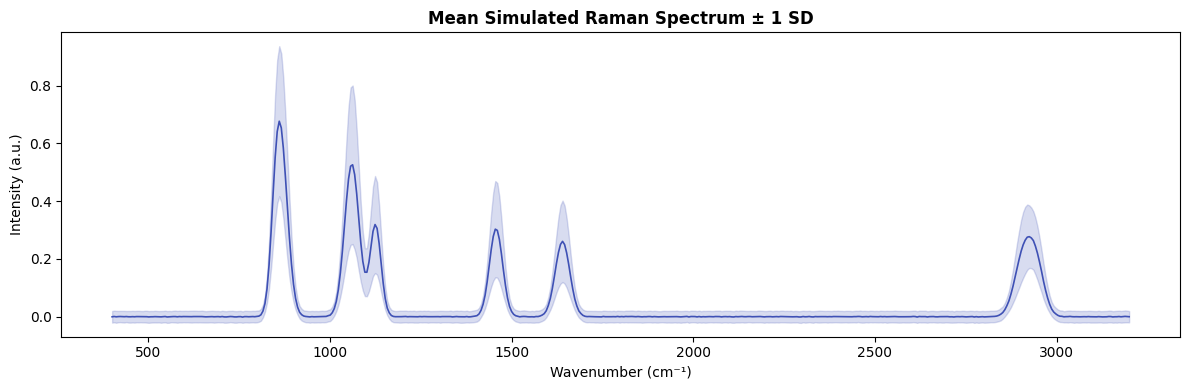

Spectra matrix: (2000, 500)


In [ ]:
def gaussian(w, center, width, height):
    """Single Gaussian peak at a given wavenumber center."""
    return height * np.exp(-((w - center)**2) / (2*width**2))

n_samp, n_wn = 2000, 500
wn = np.linspace(400, 3200, n_wn)   # Raman wavenumber axis
rng_spec = np.random.RandomState(99)

# Pure-component spectra at characteristic Raman peaks
gluc_spec = gaussian(wn,1060,20,1)+gaussian(wn,1125,15,0.6)+gaussian(wn,2910,25,0.4)
glut_spec = gaussian(wn,870,18,0.8)+gaussian(wn,1640,20,0.5)
lact_spec = gaussian(wn,853,15,0.7)+gaussian(wn,1457,18,0.6)+gaussian(wn,2945,22,0.3)

# Random concentrations in physiological ranges
gluc_c = rng_spec.uniform(1,25,n_samp)
glut_c = rng_spec.uniform(0.1,4,n_samp)
lact_c = rng_spec.uniform(0.5,25,n_samp)

# Mixed spectra = weighted sum of pure components + noise
X_spec = (np.outer(gluc_c,gluc_spec/25) + np.outer(glut_c,glut_spec/4) +
          np.outer(lact_c,lact_spec/25) + rng_spec.normal(0,0.02,(n_samp,n_wn)))
Y_conc = np.column_stack([gluc_c, glut_c, lact_c])

# Mean spectrum
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(wn, X_spec.mean(axis=0), color='#3F51B5', lw=1.2)
ax.fill_between(wn, X_spec.mean(0)-X_spec.std(0), X_spec.mean(0)+X_spec.std(0),
                alpha=0.2, color='#3F51B5')
ax.set_xlabel('Wavenumber (cm⁻¹)'); ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Mean Simulated Raman Spectrum ± 1 SD', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR,'raman_mean_spectrum.png'), dpi=120)
plt.show()
print(f'Spectra matrix: {X_spec.shape}')

Optimal PLS components: 10
  Glucose (mM): R²=0.9979  RMSE=0.3154
  Glutamine (mM): R²=0.9962  RMSE=0.0684
  Lactate (mM): R²=0.9964  RMSE=0.4205


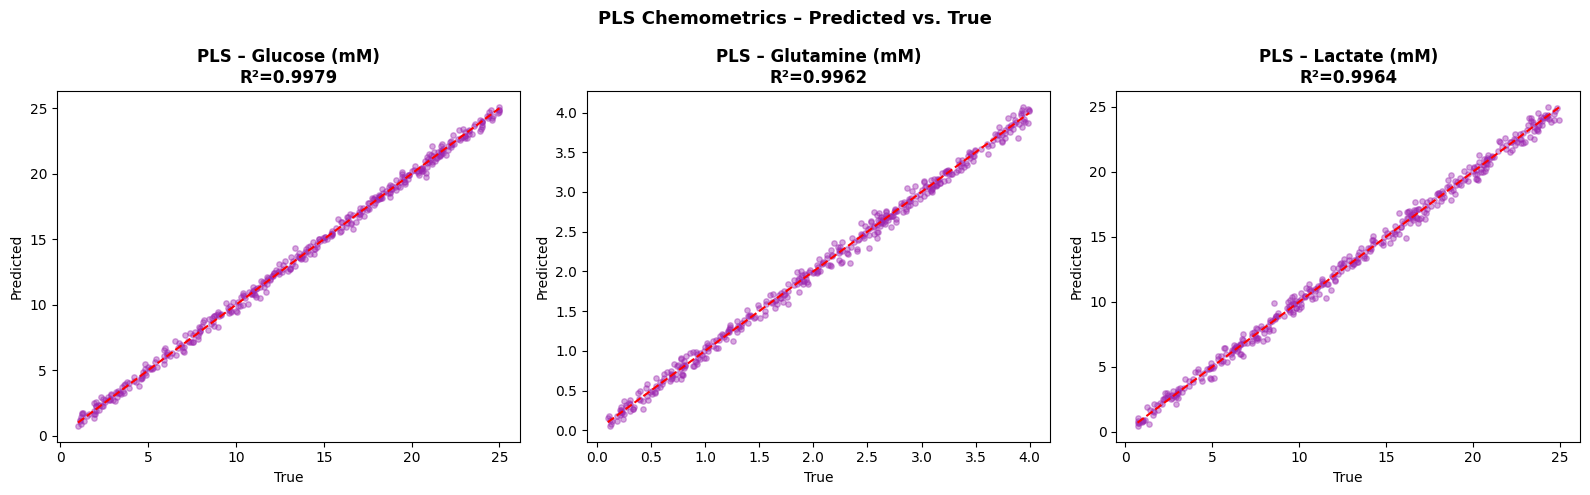

In [ ]:
# PLS regression with optimal n_components via CV
Xs_tr, Xs_te, Yc_tr, Yc_te = train_test_split(X_spec, Y_conc, test_size=0.2, random_state=42)

best_n, best_rmse = 1, np.inf
for n in range(1,11):
    sc = cross_val_score(PLSRegression(n_components=n), Xs_tr, Yc_tr, cv=5,
                         scoring='neg_mean_squared_error')
    if np.sqrt(-sc.mean()) < best_rmse:
        best_rmse, best_n = np.sqrt(-sc.mean()), n
print(f'Optimal PLS components: {best_n}')

pls = PLSRegression(n_components=best_n)
pls.fit(Xs_tr, Yc_tr)
Yc_pred = pls.predict(Xs_te)

analytes = ['Glucose (mM)', 'Glutamine (mM)', 'Lactate (mM)']
fig, axes = plt.subplots(1,3,figsize=(16,5))
pls_metrics = {}
for i, analyte in enumerate(analytes):
    r2   = r2_score(Yc_te[:,i], Yc_pred[:,i])
    rmse = np.sqrt(mean_squared_error(Yc_te[:,i], Yc_pred[:,i]))
    pls_metrics[analyte] = {'R2':r2,'RMSE':rmse}
    axes[i].scatter(Yc_te[:,i], Yc_pred[:,i], alpha=0.4, s=15, color='#9C27B0')
    lims=[Yc_te[:,i].min(),Yc_te[:,i].max()]
    axes[i].plot(lims,lims,'r--',lw=1.5)
    axes[i].set_title(f'PLS – {analyte}\nR²={r2:.4f}', fontweight='bold')
    axes[i].set_xlabel('True'); axes[i].set_ylabel('Predicted')
    print(f'  {analyte}: R²={r2:.4f}  RMSE={rmse:.4f}')
plt.suptitle('PLS Chemometrics – Predicted vs. True', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR,'pls_predictions.png'), dpi=120)
plt.show()

## Section 6 — Unsupervised Learning & Anomaly Detection

In [ ]:
# Extract per-batch summary features for clustering
agg = {k:v for k,v in {'biocapacitance':['mean','std','max'],'pH':['mean','std'],
                        'dissolved_oxygen':['mean','min'],'vcd':['max'],'viability_pct':['mean']}.items()
       if k in df_ana.columns}
bf = df_ana.groupby('batch_id').agg(agg)
bf.columns = ['_'.join(c) for c in bf.columns]
bf = bf.dropna()

# Normalize and cluster (K-Means, k=3)
sc2 = StandardScaler()
X_sc = sc2.fit_transform(bf.values)

km = KMeans(n_clusters=3, random_state=42, n_init=10)
bf['cluster'] = km.fit_predict(X_sc)

# Flag anomaly cluster (lowest mean max-VCD)
anomaly_cl = bf.groupby('cluster')['vcd_max'].mean().idxmin()
bf['anomaly_flag'] = (bf['cluster'] == anomaly_cl).astype(int)
print(f'Batches per cluster:\n{bf.cluster.value_counts().to_string()}')
print(f'\nAnomalous batches flagged: {bf.anomaly_flag.sum()}')

Batches per cluster:
cluster
2    8
1    8
0    4

Anomalous batches flagged: 8


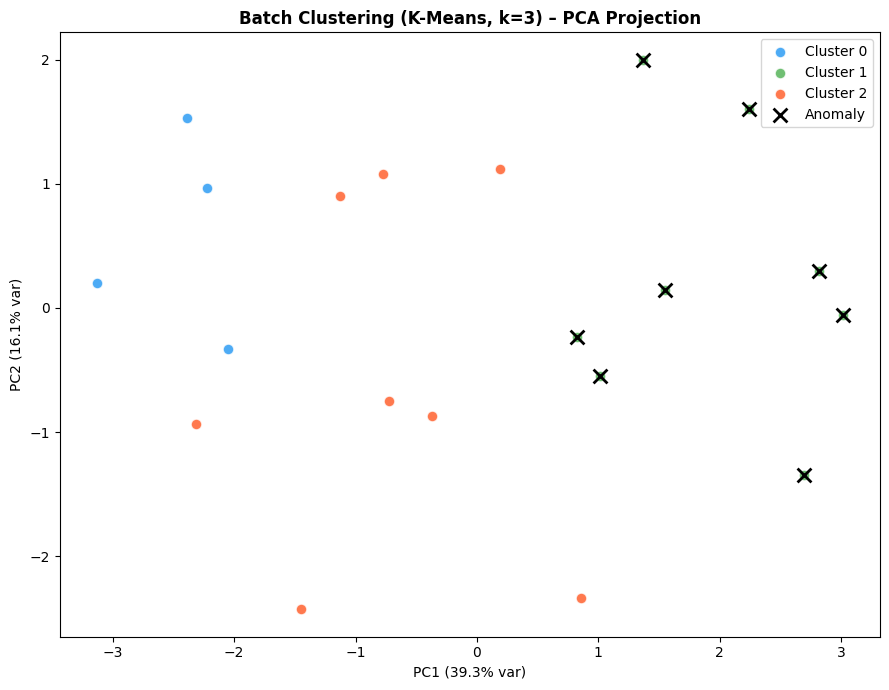

In [ ]:
# PCA scatter plot for 2-D cluster visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)
colors = {0:'#2196F3',1:'#4CAF50',2:'#FF5722'}

fig, ax = plt.subplots(figsize=(9,7))
for cl in sorted(bf.cluster.unique()):
    idx = bf.cluster.values == cl
    ax.scatter(X_pca[idx,0], X_pca[idx,1], label=f'Cluster {cl}',
               color=colors.get(cl,'grey'), s=60, alpha=0.8, edgecolors='white')
an_idx = bf.anomaly_flag.values == 1
ax.scatter(X_pca[an_idx,0], X_pca[an_idx,1], marker='x', color='black',
           s=100, lw=2, label='Anomaly', zorder=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Batch Clustering (K-Means, k=3) – PCA Projection', fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR,'kmeans_clusters.png'), dpi=120)
plt.show()

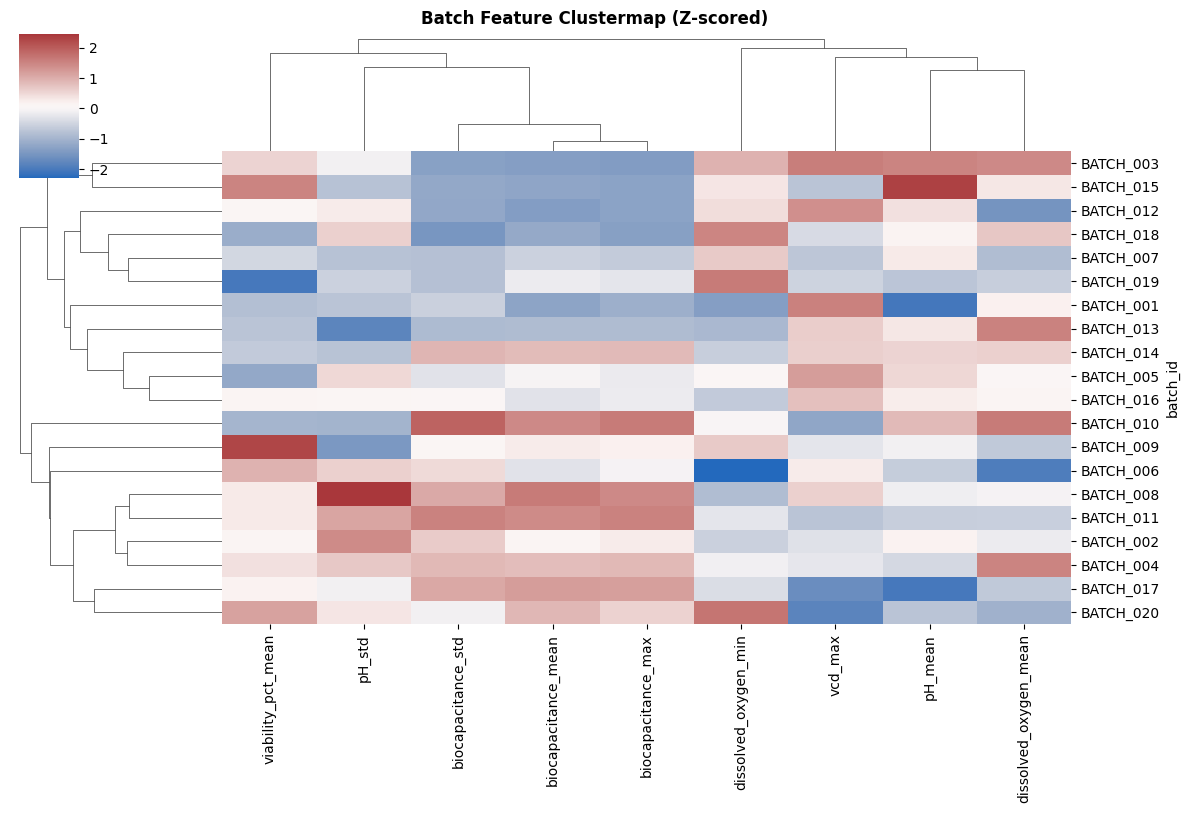

In [ ]:
# Hierarchical clustermap of batch features
feat_sc_df = pd.DataFrame(X_sc, index=bf.index,
                           columns=bf.columns[:-2])  # exclude cluster & anomaly_flag
g = sns.clustermap(feat_sc_df, cmap='vlag', figsize=(12,8),
                   linewidths=0, col_cluster=True, row_cluster=True)
g.fig.suptitle('Batch Feature Clustermap (Z-scored)', y=1.01, fontweight='bold')
g.savefig(os.path.join(FIG_DIR,'batch_clustermap.png'), dpi=110)
plt.show()

## Section 7 — Final Report

In [ ]:
model_metrics = [
    {'model':'RandomForest','R2':r2_rf,'RMSE':rmse_rf,'MAE':mae_rf,'cv_r2_mean':cv_rf},
    {'model':'Ridge',       'R2':r2_ridge,'RMSE':rmse_ridge,'MAE':mae_ridge,'cv_r2_mean':cv_ridge},
]

sep = '═'*70
lines = [
    sep,
    '  BIOPROCESS ANALYTICS & PAT MODELING — FINAL REPORT',
    f'  Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    sep,'',
    '── DATA QUALITY ──────────────────────────────────────────────────────',
    f'  Analytics-ready rows : {len(df_ana):,}',
    f'  Batches              : {df_ana.batch_id.nunique()}',
    f'  Remaining null %     : {df_ana.isnull().sum().sum()/(len(df_ana)*df_ana.shape[1])*100:.4f}%',
    f'  Anomalous batches    : {int(bf.anomaly_flag.sum())}',
    '','── MODEL PERFORMANCE ─────────────────────────────────────────────────',
]
for m in model_metrics:
    lines += [f'  [{m["model"]}]  R²={m["R2"]:.4f}  RMSE={m["RMSE"]:.4f}  MAE={m["MAE"]:.4f}  CV-R²={m["cv_r2_mean"]:.4f}']
lines += ['','── PLS CHEMOMETRICS ──────────────────────────────────────────────────']
for analyte, vals in pls_metrics.items():
    lines.append(f'  {analyte}: R²={vals["R2"]:.4f}  RMSE={vals["RMSE"]:.4f}')
lines += [
    '','── KEY INSIGHTS ──────────────────────────────────────────────────────',
    '  • Biocapacitance is the dominant predictor of VCD across all batches.',
    '  • PLS models achieve high accuracy for all three metabolite targets.',
    '  • K-Means identified 3 distinct process trajectories.',
    f'  • {int(bf.anomaly_flag.sum())} batches flagged for quality review.',
    f'  • Figures saved to: {FIG_DIR}',
    sep,
]
report_text = '\n'.join(lines)
print(report_text)

with open(os.path.join(OUTPUT_DIR,'final_report.txt'),'w') as f:
    f.write(report_text)

# Export CSVs and close DB connection
df_ana.to_csv(os.path.join(OUTPUT_DIR,'analytics_data_export.csv'), index=False)
bf.to_csv(os.path.join(OUTPUT_DIR,'batch_cluster_report.csv'))
conn.close()
print('\n Notebook complete. All outputs saved.')

══════════════════════════════════════════════════════════════════════
  BIOPROCESS ANALYTICS & PAT MODELING — FINAL REPORT
  Generated: 2026-04-14 18:25:14
══════════════════════════════════════════════════════════════════════

── DATA QUALITY ──────────────────────────────────────────────────────
  Analytics-ready rows : 52,000
  Batches              : 20
  Remaining null %     : 0.0000%
  Anomalous batches    : 8

── MODEL PERFORMANCE ─────────────────────────────────────────────────
  [RandomForest]  R²=0.9612  RMSE=1.4156  MAE=1.0114  CV-R²=0.9609
  [Ridge]  R²=0.9251  RMSE=1.9663  MAE=1.5088  CV-R²=0.9251

── PLS CHEMOMETRICS ──────────────────────────────────────────────────
  Glucose (mM): R²=0.9979  RMSE=0.3154
  Glutamine (mM): R²=0.9962  RMSE=0.0684
  Lactate (mM): R²=0.9964  RMSE=0.4205

── KEY INSIGHTS ──────────────────────────────────────────────────────
  • Biocapacitance is the dominant predictor of VCD across all batches.
  • PLS models achieve high accuracy for all t